In [29]:
def read_conll_file(file_path):
    sentences, tags = [], []
    current_sentence, current_tags = [], []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Nếu gặp dòng trống -> Chuyển sang câu mới
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    tags.append(current_tags)
                    current_sentence, current_tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    word = parts[0]
                    tag = parts[-1]
                    current_sentence.append(word)
                    current_tags.append(tag)

    # Lưu câu cuối cùng nếu file không kết thúc bằng dòng trống
    if current_sentence:
        sentences.append(current_sentence)
        tags.append(current_tags)

    return sentences, tags

# Đọc dữ liệu
train_sentences, train_tags = read_conll_file("/kaggle/input/datasets/tuantc2306/training-data1/train.txt")

In [30]:
len(train_sentences)

4573

=== THỐNG KÊ SỐ LƯỢNG CÂU CHỨA THỰC THỂ THEO ĐỘ DÀI ===
- Số câu chứa thực thể 1 chữ: 642 câu
- Số câu chứa thực thể 2 chữ: 1894 câu
- Số câu chứa thực thể 3 chữ: 1801 câu
- Số câu chứa thực thể 4 chữ: 1593 câu
- Số câu chứa thực thể 5 chữ: 917 câu
- Số câu chứa thực thể 6 chữ: 449 câu
- Số câu chứa thực thể 7 chữ: 232 câu
- Số câu chứa thực thể 8 chữ: 153 câu
- Số câu chứa thực thể >= 9 chữ: 372 câu


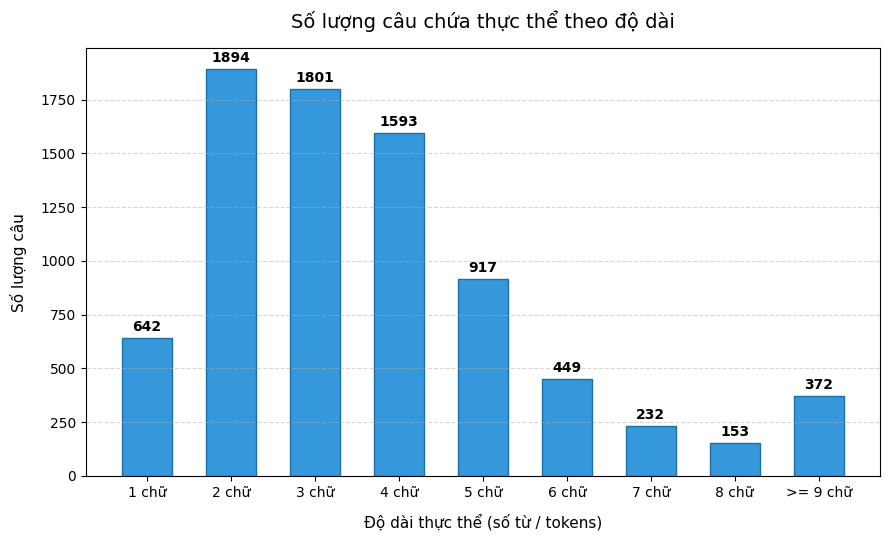

In [31]:
import matplotlib.pyplot as plt
from collections import defaultdict

def extract_entities_with_lengths(tags):
    """
    Trích xuất độ dài (số từ/tokens) của từng thực thể trong câu theo chuẩn BIO/IOB.
    """
    entity_lengths = []
    current_length = 0

    for tag in tags:
        if tag.startswith('B-'):
            if current_length > 0:
                entity_lengths.append(current_length)
            current_length = 1
        elif tag.startswith('I-'):
            if current_length > 0:
                current_length += 1
            else:
                # Trường hợp thẻ I- xuất hiện không có B- phía trước
                current_length = 1
        else:  # Thẻ 'O'
            if current_length > 0:
                entity_lengths.append(current_length)
                current_length = 0

    if current_length > 0:
        entity_lengths.append(current_length)

    return entity_lengths

# 1. Đọc dữ liệu bằng hàm read_conll_file đã có
# train_sentences, train_tags = read_conll_file("/kaggle/input/datasets/tuantc2306/training-data1/train.txt")

# Khởi tạo bộ đếm số lượng câu chứa thực thể tương ứng với từng mốc độ dài
sentence_counts = {
    '1 chữ': 0,
    '2 chữ': 0,
    '3 chữ': 0,
    '4 chữ': 0,
    '5 chữ': 0,
    '6 chữ': 0,
    '7 chữ': 0,
    '8 chữ': 0,
    '>= 9 chữ': 0  # Nhiều hơn hoặc bằng 6 chữ
}

# 2. Duyệt qua từng câu để thống kê
for tags in train_tags:
    lengths = extract_entities_with_lengths(tags)
    unique_lengths = set(lengths)  # Dùng set để tránh đếm trùng nhiều lần trong cùng 1 câu

    if 1 in unique_lengths:
        sentence_counts['1 chữ'] += 1
    if 2 in unique_lengths:
        sentence_counts['2 chữ'] += 1
    if 3 in unique_lengths:
        sentence_counts['3 chữ'] += 1
    if 4 in unique_lengths:
        sentence_counts['4 chữ'] += 1
    if 5 in unique_lengths:
        sentence_counts['5 chữ'] += 1
    if 6 in unique_lengths:
        sentence_counts['6 chữ'] += 1
    if 7 in unique_lengths:
        sentence_counts['7 chữ'] += 1
    if 8 in unique_lengths:
        sentence_counts['8 chữ'] += 1
    if any(l >= 9 for l in unique_lengths):
        sentence_counts['>= 9 chữ'] += 1

# 3. In kết quả số lượng câu ra màn hình
print("=== THỐNG KÊ SỐ LƯỢNG CÂU CHỨA THỰC THỂ THEO ĐỘ DÀI ===")
for category, count in sentence_counts.items():
    print(f"- Số câu chứa thực thể {category}: {count} câu")

# 4. Trực quan hóa dữ liệu bằng biểu đồ cột
categories = list(sentence_counts.keys())
values = list(sentence_counts.values())

plt.figure(figsize=(9, 5.5))
bars = plt.bar(categories, values, color='#3498db', edgecolor='#1d6fa5', width=0.6)

# Hiển thị giá trị cụ thể trên đầu mỗi cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + (max(values) * 0.01),
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Số lượng câu chứa thực thể theo độ dài', fontsize=14, pad=15)
plt.xlabel('Độ dài thực thể (số từ / tokens)', fontsize=11, labelpad=10)
plt.ylabel('Số lượng câu', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
# def extract_entities(words, tags):
#     """Trích xuất danh sách các thực thể kèm độ dài (số từ) trong câu."""
#     entities = []
#     curr_tokens = []
#     curr_type = None

#     for w, t in zip(words, tags):
#         if t.startswith('B-'):
#             if curr_tokens:
#                 entities.append((curr_type, " ".join(curr_tokens), len(curr_tokens)))
#             curr_tokens = [w]
#             curr_type = t[2:]
#         elif t.startswith('I-') and curr_tokens:
#             curr_tokens.append(w)
#         else:
#             if curr_tokens:
#                 entities.append((curr_type, " ".join(curr_tokens), len(curr_tokens)))
#                 curr_tokens = []
#                 curr_type = None

#     if curr_tokens:
#         entities.append((curr_type, " ".join(curr_tokens), len(curr_tokens)))

#     return entities
# filtered_sentences = []
# filtered_tags = []

# for sentence, tags in zip(train_sentences, train_tags):
#     entities = extract_entities(sentence, tags)
    
#     # Có entity và TẤT CẢ các entity trong câu đều có độ dài < 9
#     if len(entities) > 0 and all(length < 9 for _, _, length in entities):
#         filtered_sentences.append(sentence)
#         filtered_tags.append(tags)

# print(f"Tổng số câu đạt điều kiện: {len(filtered_sentences)}")
# print(f"Tổng số nhãn tương ứng: {len(filtered_tags)}")
# train_sentences, train_tags = filtered_sentences, filtered_tags

Tổng số câu đạt điều kiện: 4201
Tổng số nhãn tương ứng: 4201


In [6]:
# def extract_entity_windows(sentences, tags, context_size=1):
#     """
#     context_size=1 tương ứng với việc lấy 1 nhãn 'O' phía trước và 1 nhãn 'O' phía sau cụm B-...-I.
#     """
#     oversampled_sentences = []
#     oversampled_tags = []
    
#     for sent, tag_list in zip(sentences, tags):
#         # 1. Luôn thêm câu gốc vào tập dữ liệu mới
#         oversampled_sentences.append(sent)
#         oversampled_tags.append(tag_list)
        
#         # 2. Duyệt tìm các cụm thực thể để cắt đoạn con
#         n = len(tag_list)
#         i = 0
#         while i < n:
#             if tag_list[i].startswith('B-'):
#                 start_entity = i
#                 end_entity = i + 1
                
#                 # Tìm toàn bộ token 'I-' đi kèm
#                 while end_entity < n and tag_list[end_entity].startswith('I-'):
#                     end_entity += 1
            
#                 # Mở rộng lấy cửa sổ context_size token 'O' phía trước và phía sau
#                 start_idx = max(0, start_entity - context_size)
#                 end_idx = min(n - 1, end_entity + context_size)
#                 for x in range(5):
#                     sub_sent = sent[start_idx:end_idx]
#                     sub_tags = tag_list[start_idx:end_idx]
                    
#                     # Thêm đoạn trích xuất vào tập dữ liệu
#                     oversampled_sentences.append(sub_sent)
#                     oversampled_tags.append(sub_tags)
                    
#                 i = end_entity
#             else:
#                 i += 1
                
#     return oversampled_sentences, oversampled_tags


# # Thực hiện tạo tập dữ liệu mới
# oversampled_train_sentences, oversampled_train_tags = extract_entity_windows(
#     train_sentences, 
#     train_tags, 
#     context_size=1
# )

# print(f"Số lượng mẫu ban đầu : {len(train_sentences)}")
# print(f"Số lượng mẫu sau khi oversample: {len(oversampled_train_sentences)}")

# # In thử 3 mẫu câu trích xuất ngắn vừa tạo
# print("\n--- Ví dụ mẫu trích xuất ngắn ---")
# for s, t in zip(oversampled_train_sentences[-5:], oversampled_train_tags[-5:]):
#     if len(s) <= 6:
#         print("Words:", s)
#         print("Tags :", t)
#         print("-" * 30)

Số lượng mẫu ban đầu : 4573
Số lượng mẫu sau khi oversample: 59798

--- Ví dụ mẫu trích xuất ngắn ---
Words: ['virus', 'viêm', 'giác', 'mạc', 'có']
Tags : ['B-nguyen_nhan_benh', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O']
------------------------------
Words: ['virus', 'viêm', 'giác', 'mạc', 'có']
Tags : ['B-nguyen_nhan_benh', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O']
------------------------------
Words: ['virus', 'viêm', 'giác', 'mạc', 'có']
Tags : ['B-nguyen_nhan_benh', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O']
------------------------------
Words: ['virus', 'viêm', 'giác', 'mạc', 'có']
Tags : ['B-nguyen_nhan_benh', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O']
------------------------------
Words: ['virus', 'viêm', 'giác', 'mạc', 'có']
Tags : ['B-nguyen_nhan_benh', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O']
------------------------------


In [3]:
import random
from collections import defaultdict
from copy import deepcopy

def extract_entities(sentences, tags):
    """
    Trích xuất danh mục các thực thể theo từng nhãn từ tập dữ liệu train.
    """
    entity_bank = defaultdict(list)
    
    for sent, tag_list in zip(sentences, tags):
        idx = 0
        while idx < len(sent):
            tag = tag_list[idx]
            if tag.startswith("B-"):
                entity_type = tag[2:]
                ent_words = [sent[idx]]
                
                # Gom các token I- tương ứng
                idx += 1
                while idx < len(sent) and tag_list[idx] == f"I-{entity_type}":
                    ent_words.append(sent[idx])
                    idx += 1
                
                entity_bank[entity_type].append(ent_words)
            else:
                idx += 1

    # Loại bỏ các cụm thực thể trùng lặp trong mỗi nhãn
    for ent_type in entity_bank:
        unique_entities = []
        for ent in entity_bank[ent_type]:
            if ent not in unique_entities:
                unique_entities.append(ent)
        entity_bank[ent_type] = unique_entities
        
    return entity_bank


def augment_ner_by_replacement(sentences, tags, entity_bank, p_replace: float = 0.5):
    """
    Tăng cường dữ liệu bằng cách hoán đổi thực thể ngẫu nhiên với một thực thể khác cùng loại.
    """
    new_sentences = []
    new_tags = []
    
    for sent, tag_list in zip(sentences, tags):
        aug_sent = []
        aug_tags = []
        idx = 0
        changed = False
        
        while idx < len(sent):
            tag = tag_list[idx]
            if tag.startswith("B-"):
                entity_type = tag[2:]
                curr_ent = [sent[idx]]
                idx += 1
                while idx < len(sent) and tag_list[idx] == f"I-{entity_type}":
                    curr_ent.append(sent[idx])
                    idx += 1
                
                # Quyết định thay thế thực thể với xác suất p_replace
                if random.random() < p_replace and len(entity_bank[entity_type]) > 1:
                    replacement = random.choice(entity_bank[entity_type])
                    while replacement == curr_ent and len(entity_bank[entity_type]) > 1:
                        replacement = random.choice(entity_bank[entity_type])
                    
                    aug_sent.extend(replacement)
                    aug_tags.append(f"B-{entity_type}")
                    aug_tags.extend([f"I-{entity_type}"] * (len(replacement) - 1))
                    changed = True
                else:
                    aug_sent.extend(curr_ent)
                    aug_tags.append(f"B-{entity_type}")
                    aug_tags.extend([f"I-{entity_type}"] * (len(curr_ent) - 1))
            else:
                aug_sent.append(sent[idx])
                aug_tags.append(tag)
                idx += 1
                
        # Chỉ lưu nếu câu có sự thay đổi thực thể
        if changed:
            new_sentences.append(aug_sent)
            new_tags.append(aug_tags)
            
    return new_sentences, new_tags


# ==========================================
# 1. Trích xuất kho thực thể từ train_sentences
# ==========================================
entity_bank = extract_entities(train_sentences, train_tags)
print("Thống kê số lượng thực thể duy nhất trích xuất được:")
for ent_type, ents in entity_bank.items():
    print(f" - {ent_type}: {len(ents)} thực thể")

# ==========================================
# 2. Sinh dữ liệu tăng cường
# ==========================================
aug_sentences, aug_tags = augment_ner_by_replacement(
    train_sentences, 
    train_tags, 
    entity_bank, 
    p_replace=0.6  # Tỷ lệ thay thế các entity bắt gặp trong câu
)

print(f"\nSố câu ban đầu: {len(train_sentences)}")
print(f"Số câu mới sinh thêm: {len(aug_sentences)}")

# Gộp tập gốc và tập augment
final_train_sentences = train_sentences + aug_sentences
final_train_tags = train_tags + aug_tags

print(f"Tổng số câu train sau khi Augmentation: {len(final_train_sentences)}")

Thống kê số lượng thực thể duy nhất trích xuất được:
 - ten_benh: 1438 thực thể
 - trieu_chung_benh: 1127 thực thể
 - bien_phap_chan_doan: 469 thực thể
 - bien_phap_dieu_tri: 1022 thực thể
 - nguyen_nhan_benh: 623 thực thể

Số câu ban đầu: 4573
Số câu mới sinh thêm: 3621
Tổng số câu train sau khi Augmentation: 8194


In [4]:
import random
from collections import defaultdict

# 1. Từ điển mở rộng chuyên cho nguyen_nhan_benh (đã tách từ theo khoảng trắng đồng bộ)
EXTERNAL_CAUSES = [
    ["vi", "khuẩn", "Helicobacter", "pylori"],
    ["virus", "HBV"],
    ["virus", "HCV"],
    ["virus", "Epstein", "-", "Barr"],
    ["nhiễm", "trùng", "vi", "khuẩn", "tụ", "cầu"],
    ["nhiễm", "xoắn", "khuẩn"],
    ["đột", "biến", "gen", "di", "truyền"],
    ["hút", "thuốc", "lá", "chủ", "động"],
    ["hút", "thuốc", "lá", "thụ", "động"],
    ["lạm", "dụng", "rượu", "bia"],
    ["tiếp", "xúc", "bức", "xạ", "ion", "hóa"],
    ["nhiễm", "độc", "hóa", "chất"],
    ["thói", "quen", "ăn", "uống", "nhiều", "dầu", "mỡ"],
    ["chế", "độ", "ăn", "ít", "chất", "xơ"],
    ["căng", "thẳng", "kéo", "dài"],
    ["thức", "khuya", "thường", "xuyên"],
    ["béo", "phì"],
    ["lối", "sống", "ít", "vận", "động"],
    ["nguồn", "nước", "bị", "ô", "nhiễm"],
    ["khói", "bụi", "công", "nghiệp"]
]

# 2. Gộp kho từ vựng nguyen_nhan_benh đã trích xuất từ tập gốc với từ điển mở rộng
all_causes = entity_bank.get("nguyen_nhan_benh", []) + EXTERNAL_CAUSES

# Lọc trùng lặp
unique_causes = []
for c in all_causes:
    if c not in unique_causes:
        unique_causes.append(c)

print(f"Tổng số lượng mẫu nguyên nhân dùng để thay thế: {len(unique_causes)}")


# 3. Hàm chuyên biệt tăng cường cho thực thể nguyen_nhan_benh
def augment_target_entity(sentences, tags, target_label="nguyen_nhan_benh", candidate_pool=None, num_repeats=3):
    """
    Tìm các câu chứa target_label và sinh ra num_repeats biến thể mới cho mỗi câu.
    """
    target_b = f"B-{target_label}"
    target_i = f"I-{target_label}"
    
    aug_sents = []
    aug_tags = []
    
    for sent, tag_list in zip(sentences, tags):
        # Chỉ xử lý các câu có chứa nhãn cần tăng cường
        if target_b not in tag_list:
            continue
            
        for _ in range(num_repeats):
            new_sent = []
            new_tag = []
            idx = 0
            
            while idx < len(sent):
                if tag_list[idx] == target_b:
                    curr_ent = [sent[idx]]
                    idx += 1
                    while idx < len(sent) and tag_list[idx] == target_i:
                        curr_ent.append(sent[idx])
                        idx += 1
                    
                    # Chọn 1 nguyên nhân thay thế ngẫu nhiên khác với cụm hiện tại
                    replacement = random.choice(candidate_pool)
                    while replacement == curr_ent and len(candidate_pool) > 1:
                        replacement = random.choice(candidate_pool)
                        
                    new_sent.extend(replacement)
                    new_tag.append(target_b)
                    new_tag.extend([target_i] * (len(replacement) - 1))
                else:
                    new_sent.append(sent[idx])
                    new_tag.append(tag_list[idx])
                    idx += 1
                    
            aug_sents.append(new_sent)
            aug_tags.append(new_tag)
            
    return aug_sents, aug_tags


# 4. Thực hiện Augmentation trên tập dữ liệu train ban đầu
extra_sents, extra_tags = augment_target_entity(
    sentences=train_sentences,
    tags=train_tags,
    target_label="nguyen_nhan_benh",
    candidate_pool=unique_causes,
    num_repeats=3  # Mỗi câu chứa nguyen_nhan_benh sẽ được nhân bản tạo ra 3 biến thể mới
)

print(f"\nSố câu mới được sinh thêm cho riêng 'nguyen_nhan_benh': {len(extra_sents)}")

# 5. Gộp vào final_train_sentences
final_train_sentences = final_train_sentences + extra_sents
final_train_tags = final_train_tags + extra_tags

print(f"Tổng số câu train sau cùng: {len(final_train_sentences)}")


# 6. Kiểm tra lại số lượng thực thể nguyen_nhan_benh sau khi tăng cường
count_target = sum(tag_list.count("B-nguyen_nhan_benh") for tag_list in final_train_tags)
print(f"Tổng số lượt xuất hiện của thực thể nguyen_nhan_benh trong tập train mới: {count_target}")

Tổng số lượng mẫu nguyên nhân dùng để thay thế: 642

Số câu mới được sinh thêm cho riêng 'nguyen_nhan_benh': 1563
Tổng số câu train sau cùng: 9757
Tổng số lượt xuất hiện của thực thể nguyen_nhan_benh trong tập train mới: 4145


In [73]:
# def check_has_long_entity(words, tags, target_entity="nguyen_nhan_benh", max_char_len=6):
#     """
#     Kiểm tra xem câu có thực thể target_entity nào có độ dài chuỗi ký tự > max_char_len hay không.
#     (Nếu tính theo số từ/tokens thì đổi: len(current_tokens) > 5)
#     """
#     in_entity = False
#     current_tokens = []
    
#     for word, tag in zip(words, tags):
#         if tag == f"B-{target_entity}":
#             if in_entity:
#                 entity_text = " ".join(current_tokens)
#                 if len(entity_text) > max_char_len:
#                     return True
#             in_entity = True
#             current_tokens = [word]
#         elif tag == f"I-{target_entity}" and in_entity:
#             current_tokens.append(word)
#         else:
#             if in_entity:
#                 entity_text = " ".join(current_tokens)
#                 if len(entity_text) > max_char_len:
#                     return True
#                 in_entity = False
#                 current_tokens = []
                
#     # Kiểm tra thực thể ở cuối câu
#     if in_entity:
#         entity_text = " ".join(current_tokens)
#         if len(entity_text) > max_char_len:
#             return True

#     return False


# def filter_sentences(sentences, tags, target_entity="nguyen_nhan_benh", max_char_len=9):
#     filtered_sentences = []
#     filtered_tags = []
    
#     for words, t_list in zip(sentences, tags):
#         if not check_has_long_entity(words, t_list, target_entity, max_char_len):
#             filtered_sentences.append(words)
#             filtered_tags.append(t_list)
            
#     return filtered_sentences, filtered_tags

# print(f"Số câu ban đầu: {len(final_train_sentences)}")
# final_train_sentences, final_train_tags = filter_sentences(
#     final_train_sentences, 
#     final_train_tags, 
#     target_entity="nguyen_nhan_benh", 
#     max_char_len=10
# )

# print(f"Số câu sau khi lọc: {len(final_train_sentences)}")

Số câu ban đầu: 8166
Số câu sau khi lọc: 7324


In [5]:
print(final_train_sentences[5456])
print(final_train_tags[5456])

['những', 'người', 'bị', 'bệnh', 'dị', 'ứng', 'hoặc', 'optica', 'neuromyelitis', 'có', 'thể', 'đôi', 'khi', 'bị', 'tấn', 'công', 'tái', 'phát', 'của', 'amip', 'sau', 'khi', 'họ', 'đã', 'cải', 'thiện', 'từ', 'các', 'tập', 'ban', 'đầu', '.']
['O', 'O', 'O', 'B-ten_benh', 'I-ten_benh', 'I-ten_benh', 'O', 'B-ten_benh', 'I-ten_benh', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ten_benh', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [6]:
def save_conll_file(file_path, sentences, tags):
    with open(file_path, 'w', encoding='utf-8') as f:
        for sent, tag_list in zip(sentences, tags):
            for word, tag in zip(sent, tag_list):
                f.write(f"{word} {tag}\n")
            f.write("\n")

save_conll_file("train_augmented.txt", final_train_sentences, final_train_tags)
print("Đã lưu thành công tập train_augmented.txt!")

Đã lưu thành công tập train_augmented.txt!


In [5]:
# Lọc ra danh sách các nhãn duy nhất từ tập dữ liệu
unique_tags = set(tag for doc in train_tags for tag in doc)
unique_tags.add('O') # Đảm bảo luôn có nhãn 'O'

# Tạo từ điển
tag2id = {tag: id for id, tag in enumerate(sorted(unique_tags))}
id2tag = {id: tag for tag, id in tag2id.items()}

print(f"Tổng số nhãn: {len(tag2id)}")
print(tag2id)

Tổng số nhãn: 11
{'B-bien_phap_chan_doan': 0, 'B-bien_phap_dieu_tri': 1, 'B-nguyen_nhan_benh': 2, 'B-ten_benh': 3, 'B-trieu_chung_benh': 4, 'I-bien_phap_chan_doan': 5, 'I-bien_phap_dieu_tri': 6, 'I-nguyen_nhan_benh': 7, 'I-ten_benh': 8, 'I-trieu_chung_benh': 9, 'O': 10}


In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class NERDataset(Dataset):
    def __init__(self, sentences, tags, tokenizer, tag2id, max_len=128):
        self.sentences = sentences
        self.tags = tags
        self.tokenizer = tokenizer
        self.tag2id = tag2id
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, item):
        words = self.sentences[item]
        labels = self.tags[item]

        # 1. Khởi tạo mảng với token <s> (Bắt đầu câu)
        tokenized_sentence = [self.tokenizer.cls_token_id]
        aligned_labels = [self.tag2id['O']] # Token <s> mang nhãn 'O'

        # 2. Xử lý từng từ và nhãn
        for word, label in zip(words, labels):
            tokens = self.tokenizer.tokenize(word)
            token_ids = self.tokenizer.convert_tokens_to_ids(tokens)

            tokenized_sentence.extend(token_ids)
            # Sao chép nhãn cho toàn bộ sub-words của từ đó
            aligned_labels.extend([self.tag2id[label]] * len(tokens))

        # 3. Thêm token </s> (Kết thúc câu)
        tokenized_sentence.append(self.tokenizer.sep_token_id)
        aligned_labels.append(self.tag2id['O'])

        # 4. Cắt ngắn (Truncate) nếu dài hơn max_len
        if len(tokenized_sentence) > self.max_len:
            tokenized_sentence = tokenized_sentence[:self.max_len]
            aligned_labels = aligned_labels[:self.max_len]

        # 5. Thêm Padding (Bù số 0) cho đủ max_len
        pad_len = self.max_len - len(tokenized_sentence)

        input_ids = tokenized_sentence + [self.tokenizer.pad_token_id] * pad_len
        # attention_mask: 1 là từ thật, 0 là padding
        attention_mask = [1] * len(tokenized_sentence) + [0] * pad_len
        # Đối với CRF, nhãn của padding cứ đặt là 'O', CRF sẽ bỏ qua dựa vào attention_mask
        tags_ids = aligned_labels + [self.tag2id['O']] * pad_len

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'tags': torch.tensor(tags_ids, dtype=torch.long)
        }

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")


# # 3. Tạo Dataset từ dữ liệu đã oversampling
# train_dataset = NERDataset(
#     sentences=final_train_sentences,
#     tags=final_train_tags,
#     tokenizer=tokenizer,
#     tag2id=tag2id,
#     max_len=128
# )

# # 4. DataLoader giữ nguyên shuffle=True để các câu nhân bản được trộn đều
# train_dataloader = DataLoader(
#     train_dataset,
#     batch_size=128,
#     shuffle=True
# )

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
# 1. Đọc dữ liệu từ file dev.txt
dev_sentences, dev_tags = read_conll_file("/kaggle/input/datasets/tuantc2306/training-data1/dev.txt")

# 2. Khởi tạo Dataset cho tập Dev (DÙNG CHUNG tokenizer VÀ tag2id TỪ TẬP TRAIN)
dev_dataset = NERDataset(
    sentences=dev_sentences,
    tags=dev_tags,
    tokenizer=tokenizer,
    tag2id=tag2id,       # <-- Cực kỳ quan trọng: Dùng lại tag2id của train
    max_len=128
)

# 3. Khởi tạo DataLoader cho tập Dev
dev_dataloader = DataLoader(
    dev_dataset,
    batch_size=16,
    shuffle=False        # <-- Tập dev không cần trộn (shuffle)
)

In [10]:
!pip install --upgrade pip setuptools wheel
!pip install seqeval evaluate tqdm pytorch-crf pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 44.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 12.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s  0:00:00
  Created wheel for seqeval: f

In [11]:
import torch
import torch.nn as nn
from transformers import AutoModel
from torchcrf import CRF

class PhoBERT_BiLSTM_CRF(nn.Module):
    def __init__(self, phobert_path, tagset_size, lstm_hidden_dim, drop_rate=0.3, noise_std=0.01):
        super(PhoBERT_BiLSTM_CRF, self).__init__()

        # # Tham số độ lệch chuẩn của Gaussian Noise
        # self.noise_std = noise_std

        # 1. PhoBERT: Base model
        self.phobert = AutoModel.from_pretrained(phobert_path)
        phobert_hidden_size = self.phobert.config.hidden_size

        # 2. Bi-LSTM
        self.lstm = nn.LSTM(
            input_size=phobert_hidden_size,
            hidden_size=lstm_hidden_dim // 2,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        # 3. Dropout & Linear
        self.dropout = nn.Dropout(drop_rate)
        self.hidden2tag = nn.Linear(lstm_hidden_dim, tagset_size)

        # 4. CRF
        self.crf = CRF(tagset_size, batch_first=True)

    def forward(self, input_ids, attention_mask, tags=None):
        # BƯỚC 1: Lấy vector biểu diễn từ PhoBERT
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # shape: (batch_size, seq_len, hidden_size)

        # THÊM GAUSSIAN NOISE (Chỉ kích hoạt khi train)
        # if self.training and self.noise_std > 0:
        #     noise = torch.randn_like(sequence_output) * self.noise_std
        #     # Chỉ tạo nhiễu trên các token thật, bỏ qua token padding
        #     mask_expanded = attention_mask.unsqueeze(-1).expand_as(sequence_output)
        #     sequence_output = sequence_output + (noise * mask_expanded)

        # BƯỚC 2: Đi qua Bi-LSTM
        lstm_out, _ = self.lstm(sequence_output)

        # BƯỚC 3: Tuyến tính và Dropout
        lstm_out = self.dropout(lstm_out)
        emissions = self.hidden2tag(lstm_out)

        # Ép kiểu attention_mask sang boolean cho CRF
        mask = attention_mask.bool()

        # BƯỚC 4: Loss hoặc Decode
        if tags is not None:
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return loss
        else:
            prediction = self.crf.decode(emissions, mask=mask)
            return prediction

In [12]:
# Cấu hình siêu tham số
PHOBERT_PATH = "vinai/phobert-base-v2"
TAGSET_SIZE = 11
LSTM_HIDDEN_DIM = 256
# Khởi tạo mô hình
model = PhoBERT_BiLSTM_CRF(
    phobert_path=PHOBERT_PATH,
    tagset_size=TAGSET_SIZE,
    lstm_hidden_dim=LSTM_HIDDEN_DIM,
    drop_rate=0.5
)

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

In [13]:
import torch
from torch.optim import AdamW
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup # hoặc get_cosine_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


PhoBERT_BiLSTM_CRF(
  (phobert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): 

In [14]:
from seqeval.metrics import classification_report, f1_score
from tqdm import tqdm
def evaluate_dev(best_f1_score):
    model.eval()

    # Hai list này sẽ chứa kết quả của toàn bộ tập Dev
    all_true_tags = []
    all_pred_tags = []

    with torch.no_grad():
        for batch in tqdm(dev_dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tags = batch['tags'].to(device)

            # Lấy chuỗi ID dự đoán từ mô hình (Dùng thuật toán Viterbi của CRF)
            # Vì ta không truyền tags=... vào hàm model() nên nó sẽ trả về prediction
            predictions = model(input_ids, attention_mask)

            # Chuyển tensor thực tế và mask về numpy/CPU để dễ thao tác
            true_tags_batch = tags.cpu().numpy()
            mask_batch = attention_mask.cpu().numpy()

            # Lặp qua từng câu trong Batch
            for i in range(len(true_tags_batch)):
                true_seq = []
                pred_seq = []

                # Lặp qua từng token trong câu
                for j in range(len(true_tags_batch[i])):
                    # Chỉ lấy các token thực sự (bỏ qua Padding có mask == 0)
                    if mask_batch[i][j] == 1:
                        # Dùng từ điển id2tag để chuyển ID số thành nhãn chữ (ví dụ: 'B-ten_benh')
                        true_label = id2tag[true_tags_batch[i][j]]
                        true_seq.append(true_label)

                # Lớp CRF khi decode với mask đã tự động loại bỏ padding
                # Nên predictions[i] có độ dài khớp chính xác với true_seq
                for pred_id in predictions[i]:
                    pred_seq.append(id2tag[pred_id])

                # Gom kết quả của câu vào danh sách tổng
                all_true_tags.append(true_seq)
                all_pred_tags.append(pred_seq)

    # ----------------------------------------------------
    # 3. IN BÁO CÁO SEQEVAL VÀ LƯU MÔ HÌNH
    # ----------------------------------------------------
    # In ra Precision, Recall, F1 cho từng nhãn thực thể y tế
    print("\n--- Báo cáo Đánh giá (Dev Set) ---")
    report = classification_report(all_true_tags, all_pred_tags, digits=4)
    print(report)

    # Lấy F1-score tổng quát (micro avg) để làm thước đo lưu mô hình
    current_f1 = f1_score(all_true_tags, all_pred_tags)

    if current_f1 > best_f1_score:
        best_f1_score = current_f1
        torch.save(model.state_dict(), "phobert_bilstm_crf_best_f1_aug.pth")
        print(f"=> Đã lưu mô hình tốt nhất với F1-score: {best_f1_score:.4f}!")
    return best_f1_score

In [18]:
# Tổng số tham số (bao gồm cả đóng băng và trainable)
total_params = sum(p.numel() for p in model.parameters())

# Số tham số thực sự được huấn luyện (cần tính gradient)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số: {total_params:,}")
print(f"Số tham số có thể huấn luyện: {trainable_params:,}")
print(f"Dung lượng ước tính (triệu tham số): {total_params / 1e6:.2f}M")

Tổng số tham số: 135,920,794
Số tham số có thể huấn luyện: 135,920,794
Dung lượng ước tính (triệu tham số): 135.92M


In [34]:
def freeze_phobert(model):
    for param in model.phobert.parameters():
        param.requires_grad = False

def unfreeze_from_last_layer_output(model):
    for param in model.phobert.parameters():
        param.requires_grad = True

In [37]:
import torch
from seqeval.metrics import classification_report, f1_score
from tqdm import tqdm

freeze_epochs = 2    # Số epoch đầu chỉ train LSTM + CRF
unfreeze_epochs = 8  # Số epoch sau train toàn bộ mạng
total_epochs = freeze_epochs + unfreeze_epochs
best_f1_score = 0.0 # Sử dụng F1-score để lưu mô hình thay vì Loss
print("=== GIAI ĐOẠN 1: ĐÓNG BĂNG PHOBERT ===")
freeze_phobert(model)

optimizer = AdamW([
    {'params': model.lstm.parameters(), 'lr': 1e-3},
    {'params': model.hidden2tag.parameters(), 'lr': 1e-3},
    {'params': model.crf.parameters(), 'lr': 1e-3}
])

for epoch in range(freeze_epochs):
    print(f"\n========== EPOCH {epoch + 1}/{freeze_epochs} ==========")

    # ----------------------------------------------------
    # 1. QUÁ TRÌNH TRAIN
    # ----------------------------------------------------
    model.train()
    total_train_loss = 0
    train_loop = tqdm(train_dataloader, desc=f"[Phase 1] Epoch {epoch+1}/{freeze_epochs}")

    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tags = batch['tags'].to(device)

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, tags=tags)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Train Loss trung bình: {avg_train_loss:.4f}")
    best_f1_score = evaluate_dev(best_f1_score)

print("\n=== GIAI ĐOẠN 2: MỞ KHÓA TOÀN BỘ MÔ HÌNH ===")
unfreeze_from_last_layer_output(model)
optimizer = AdamW([
    {'params': model.phobert.parameters(), 'lr': 2e-5},
    {'params': model.lstm.parameters(), 'lr': 1e-3},
    {'params': model.hidden2tag.parameters(), 'lr': 1e-3},
    {'params': model.crf.parameters(), 'lr': 1e-3}
])

total_steps_phase = len(train_dataloader) * total_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps_phase),
    num_training_steps=total_steps_phase
)

for epoch in range(unfreeze_epochs):
    print(f"\n========== EPOCH {epoch + freeze_epochs + 1 }/{total_epochs} ==========")

    # ----------------------------------------------------
    # 1. QUÁ TRÌNH TRAIN
    # ----------------------------------------------------
    model.train()
    total_train_loss = 0
    train_loop = tqdm(train_dataloader, desc=f"[Phase 1] Epoch {epoch+1}/{unfreeze_epochs}")

    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tags = batch['tags'].to(device)

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, tags=tags)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Train Loss trung bình: {avg_train_loss:.4f}")
    best_f1_score = evaluate_dev(best_f1_score)


=== GIAI ĐOẠN 1: ĐÓNG BĂNG PHOBERT ===

========== EPOCH 1/2 ==========


[Phase 1] Epoch 1/2: 100%|██████████| 89/89 [01:50<00:00,  1.24s/it, loss=1.12] 


Train Loss trung bình: 0.9266


Evaluating: 100%|██████████| 96/96 [00:13<00:00,  7.05it/s]



--- Báo cáo Đánh giá (Dev Set) ---
                     precision    recall  f1-score   support

bien_phap_chan_doan     0.6757    0.6309    0.6525       317
 bien_phap_dieu_tri     0.6907    0.7269    0.7084      1106
   nguyen_nhan_benh     0.3289    0.2273    0.2688       330
           ten_benh     0.7881    0.8131    0.8004      1894
   trieu_chung_benh     0.6392    0.6005    0.6192       761

          micro avg     0.7060    0.6978    0.7019      4408
          macro avg     0.6245    0.5998    0.6099      4408
       weighted avg     0.6955    0.6978    0.6956      4408

=> Đã lưu mô hình tốt nhất với F1-score: 0.7019!

========== EPOCH 2/2 ==========


...


--- Báo cáo Đánh giá (Dev Set) ---
                     precision    recall  f1-score   support

bien_phap_chan_doan     0.6732    0.6498    0.6613       317
 bien_phap_dieu_tri     0.6756    0.7288    0.7012      1106
   nguyen_nhan_benh     0.3195    0.2333    0.2697       330
           ten_benh     0.7919    0.8400    0.8153      1894
   trieu_chung_benh     0.6486    0.6137    0.6307       761

          micro avg     0.7042    0.7139    0.7090      4408
          macro avg     0.6218    0.6131    0.6156      4408
       weighted avg     0.6941    0.7139    0.7029      4408


========== EPOCH 10/10 ==========


[Phase 1] Epoch 8/8: 100%|██████████| 89/89 [04:35<00:00,  3.09s/it, loss=0.263]


Train Loss trung bình: 0.3500


Evaluating: 100%|██████████| 96/96 [00:13<00:00,  7.14it/s]



--- Báo cáo Đánh giá (Dev Set) ---
                     precision    recall  f1-score   support

bien_phap_chan_doan     0.6667    0.6372    0.6516       317
 bien_phap_dieu_tri     0.6960    0.7432    0.7188      1106
   nguyen_nhan_benh     0.3068    0.2333    0.2651       330
           ten_benh     0.8060    0.8226    0.8142      1894
   trieu_chung_benh     0.6491    0.6005    0.6239       761

          micro avg     0.7127    0.7069    0.7098      4408
          macro avg     0.6249    0.6074    0.6147      4408
       weighted avg     0.7039    0.7069    0.7046      4408

=> Đã lưu mô hình tốt nhất với F1-score: 0.7098!


In [15]:
import torch
from seqeval.metrics import classification_report
from tqdm import tqdm

# 1. Định nghĩa hàm đánh giá dùng chung
def evaluate_model(model, dataloader, device, id2tag, desc="Evaluating"):
    model.eval() # Chuyển sang chế độ đánh giá
    all_true_tags = []
    all_pred_tags = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tags = batch['tags'].to(device)

            # Dự đoán nhãn
            predictions = model(input_ids, attention_mask)

            true_tags_batch = tags.cpu().numpy()
            mask_batch = attention_mask.cpu().numpy()

            # Lặp qua từng câu để dịch ID sang Text và loại bỏ Padding
            for i in range(len(true_tags_batch)):
                true_seq = []
                pred_seq = []

                for j in range(len(true_tags_batch[i])):
                    if mask_batch[i][j] == 1:
                        true_seq.append(id2tag[true_tags_batch[i][j]])

                for pred_id in predictions[i]:
                    pred_seq.append(id2tag[pred_id])

                all_true_tags.append(true_seq)
                all_pred_tags.append(pred_seq)

    # Trả về bảng báo cáo seqeval
    return classification_report(all_true_tags, all_pred_tags, digits=4)



In [16]:
# 2. Khôi phục trọng số mô hình LoRA tốt nhất
# Chạy lại cell khởi tạo model LoRA trước khi load checkpoint này.
model.load_state_dict(torch.load("/kaggle/input/datasets/tuantc2306/improvement-model/phobert_bilstm_crf_best_f1_aug.pth", map_location=device))
model.to(device)

# 3. Tiến hành đánh giá và in kết quả
# print()
# print("="*40)
# print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TRAIN")
# print("="*40)
# train_report = evaluate_model(model, train_dataloader, device, id2tag, desc="Testing on Train")
# print(train_report)

print()
print("="*40)
print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP DEV")
print("="*40)
dev_report = evaluate_model(model, dev_dataloader, device, id2tag, desc="Testing on Dev")
print(dev_report)



BÁO CÁO ĐÁNH GIÁ TRÊN TẬP DEV


Testing on Dev: 100%|██████████| 96/96 [00:12<00:00,  7.71it/s]


                     precision    recall  f1-score   support

bien_phap_chan_doan     0.6145    0.6940    0.6519       317
 bien_phap_dieu_tri     0.6715    0.7170    0.6935      1106
   nguyen_nhan_benh     0.4403    0.3909    0.4141       330
           ten_benh     0.7987    0.8421    0.8198      1894
   trieu_chung_benh     0.6444    0.6452    0.6448       761

          micro avg     0.7031    0.7323    0.7174      4408
          macro avg     0.6339    0.6579    0.6448      4408
       weighted avg     0.7001    0.7323    0.7155      4408



In [20]:
# 1. Đọc dữ liệu từ file dev.txt
test_sentences, test_tags = read_conll_file("/kaggle/input/datasets/tuantc2306/test-data1/test.txt")

# 2. Khởi tạo Dataset cho tập Dev (DÙNG CHUNG tokenizer VÀ tag2id TỪ TẬP TRAIN)
test_dataset = NERDataset(
    sentences=test_sentences,
    tags=test_tags,
    tokenizer=tokenizer,
    tag2id=tag2id,       # <-- Cực kỳ quan trọng: Dùng lại tag2id của train
    max_len=128
)

# 3. Khởi tạo DataLoader cho tập Dev
test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False        
)

In [23]:
print("\n" + "="*40)
print("BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*40)
test_report = evaluate_model(model, test_dataloader, device, id2tag, desc="Testing on Dev")
print(test_report)


BÁO CÁO ĐÁNH GIÁ TRÊN TẬP TEST


Testing on Dev: 100%|██████████| 96/96 [00:12<00:00,  7.84it/s]


                     precision    recall  f1-score   support

bien_phap_chan_doan     0.6522    0.6892    0.6702       370
 bien_phap_dieu_tri     0.7594    0.7118    0.7348      1055
   nguyen_nhan_benh     0.3808    0.3750    0.3779       328
           ten_benh     0.7934    0.8371    0.8147      1922
   trieu_chung_benh     0.6352    0.6801    0.6569       722

          micro avg     0.7169    0.7344    0.7255      4397
          macro avg     0.6442    0.6586    0.6509      4397
       weighted avg     0.7166    0.7344    0.7249      4397



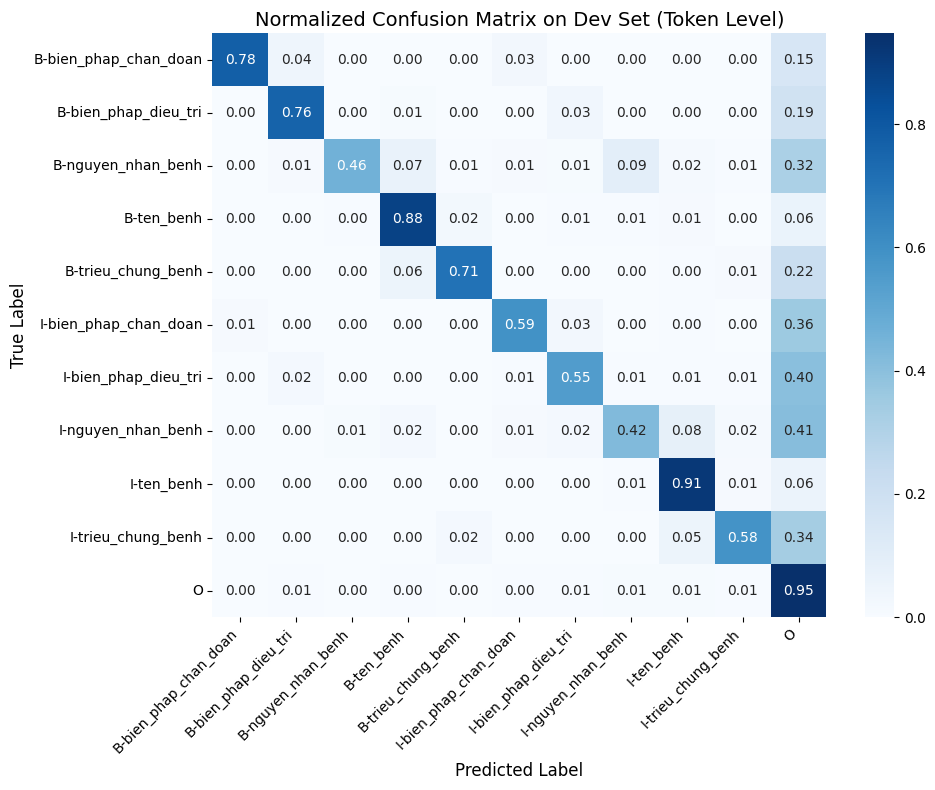

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def get_token_level_predictions(model, dataloader, device, id2tag):
    """
    Trích xuất danh sách nhãn thực tế và nhãn dự đoán ở mức token (đã bỏ qua padding/special tokens).
    """
    model.eval()
    all_true_tags = []
    all_pred_tags = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['tags'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            
            # Xử lý các dạng output trả về
            if isinstance(outputs, list):
                # Trường hợp model đã tự decode CRF ra List[List[int]]
                predictions = outputs
            elif hasattr(outputs, 'logits'):
                # Trường hợp BertForTokenClassification tiêu chuẩn
                predictions = torch.argmax(outputs.logits, dim=-1).cpu().numpy().tolist()
            elif isinstance(outputs, torch.Tensor):
                # Trường hợp model trả về Tensor logits
                predictions = torch.argmax(outputs, dim=-1).cpu().numpy().tolist()
            else:
                predictions = outputs
            
            labels = labels.cpu().numpy()
            attention_mask = attention_mask.cpu().numpy()
            
            for pred_seq, label_seq, mask_seq in zip(predictions, labels, attention_mask):
                for p, l, m in zip(pred_seq, label_seq, mask_seq):
                    # Bỏ qua token padding (mask=0) hoặc token đặc biệt (nhãn = -100)
                    if m == 1 and l != -100:
                        all_true_tags.append(id2tag[l])
                        all_pred_tags.append(id2tag[p])
                        
    return all_true_tags, all_pred_tags

# 1. Trích xuất nhãn thực tế và dự đoán trên dev_dataloader
true_tokens, pred_tokens = get_token_level_predictions(model, dev_dataloader, device, id2tag)

# 2. Lấy danh sách các nhãn duy nhất
labels_list = sorted(list(set(true_tokens + pred_tokens)))

# 3. Tính toán Confusion Matrix (chuẩn hóa theo hàng)
cm = confusion_matrix(true_tokens, pred_tokens, labels=labels_list, normalize='true')

# 4. Trực quan hóa ma trận
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=labels_list, 
    yticklabels=labels_list
)
plt.title('Normalized Confusion Matrix on Dev Set (Token Level)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_dev.png', dpi=300, bbox_inches='tight')
plt.show()

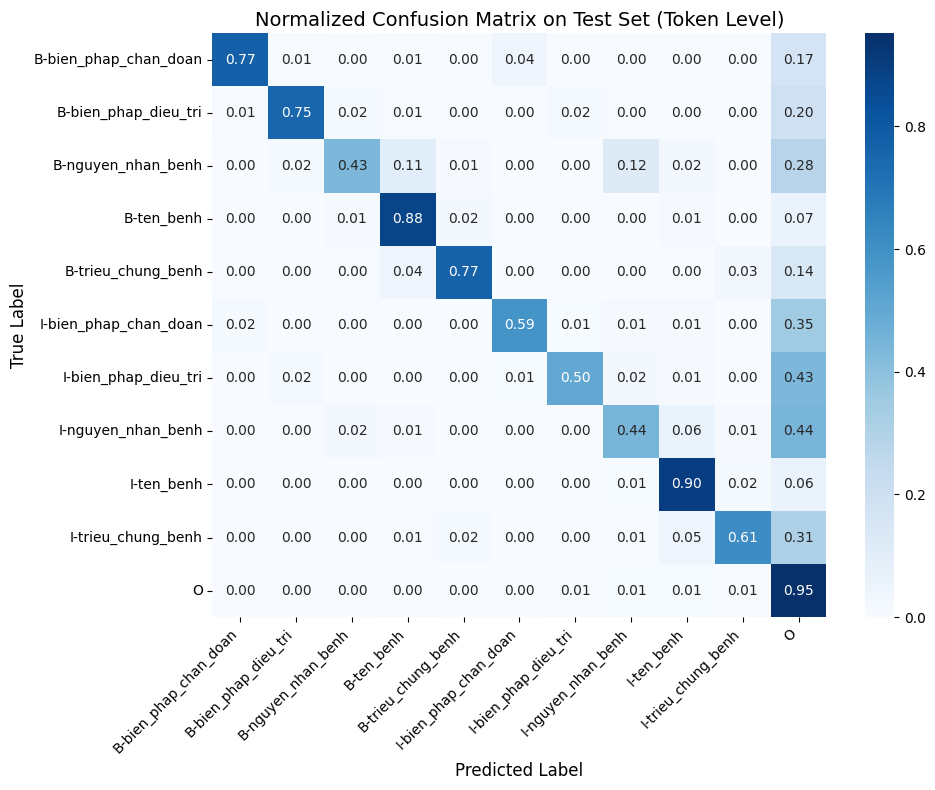

In [26]:
# 1. Trích xuất nhãn thực tế và dự đoán trên dev_dataloader
true_tokens, pred_tokens = get_token_level_predictions(model, test_dataloader, device, id2tag)

# 2. Lấy danh sách các nhãn duy nhất
labels_list = sorted(list(set(true_tokens + pred_tokens)))

# 3. Tính toán Confusion Matrix (chuẩn hóa theo hàng)
cm = confusion_matrix(true_tokens, pred_tokens, labels=labels_list, normalize='true')

# 4. Trực quan hóa ma trận
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='.2f', 
    cmap='Blues',
    xticklabels=labels_list, 
    yticklabels=labels_list
)
plt.title('Normalized Confusion Matrix on Test Set (Token Level)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
import torch
from collections import defaultdict

def extract_entities_from_tags(tokens, tags):
    """
    Gom cụm các token theo nhãn BIO thành danh sách các thực thể:
    [(start_idx, end_idx, entity_text, entity_type), ...]
    """
    entities = []
    current_entity = []
    current_type = None
    start_idx = None
    
    for idx, (token, tag) in enumerate(zip(tokens, tags)):
        clean_tok = token.replace("@@", "")
        if tag.startswith("B-"):
            if current_entity:
                entities.append((start_idx, idx - 1, " ".join(current_entity), current_type))
            current_type = tag[2:]
            current_entity = [clean_tok]
            start_idx = idx
        elif tag.startswith("I-"):
            ent_type = tag[2:]
            if current_entity and ent_type == current_type:
                current_entity.append(clean_tok)
            else:
                if current_entity:
                    entities.append((start_idx, idx - 1, " ".join(current_entity), current_type))
                current_type = ent_type
                current_entity = [clean_tok]
                start_idx = idx
        else:
            if current_entity:
                entities.append((start_idx, idx - 1, " ".join(current_entity), current_type))
                current_entity = []
                current_type = None
                start_idx = None
                
    if current_entity:
        entities.append((start_idx, len(tokens) - 1, " ".join(current_entity), current_type))
        
    return entities

def run_qualitative_error_analysis(model, dataloader, tokenizer, id2tag, device, max_samples_per_category=3):
    model.eval()
    
    # Bộ lưu trữ lỗi theo 4 nhóm định tính
    categorized_errors = {
        "Boundary Error (Lỗi ranh giới từ ghép)": [],
        "Semantic Overlap (Nhầm lẫn loại thực thể)": [],
        "False Negative (Bỏ sót thực thể thành O)": [],
        "False Positive (Dự đoán từ thường thành thực thể)": []
    }
    
    error_counts = defaultdict(int)

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            true_labels = batch['tags'].to(device)
            
            outputs = model(input_ids, attention_mask)
            
            if isinstance(outputs, list):
                best_paths = outputs
            elif hasattr(outputs, 'logits'):
                best_paths = torch.argmax(outputs.logits, dim=-1).tolist()
            elif isinstance(outputs, torch.Tensor):
                mask_crf = attention_mask.bool() if hasattr(attention_mask, 'bool') else attention_mask.byte()
                best_paths = model.crf.decode(outputs, mask=mask_crf)
            else:
                best_paths = outputs

            for i in range(len(input_ids)):
                seq_len = attention_mask[i].sum().item()
                raw_tokens = tokenizer.convert_ids_to_tokens(input_ids[i][:seq_len])
                true_ids = true_labels[i][:seq_len].tolist()
                pred_ids = best_paths[i]
                
                tokens, true_tags, pred_tags = [], [], []
                for t, tr_id, pr_id in zip(raw_tokens, true_ids, pred_ids):
                    if tr_id == -100 or t in ['<s>', '</s>', '<pad>']:
                        continue
                    tokens.append(t)
                    true_tags.append(id2tag.get(tr_id, 'O'))
                    pred_tags.append(id2tag.get(pr_id, 'O'))
                    
                sentence_str = " ".join([t.replace("@@", "") for t in tokens])
                
                true_ents = extract_entities_from_tags(tokens, true_tags)
                pred_ents = extract_entities_from_tags(tokens, pred_tags)
                
                matched_true = set()
                matched_pred = set()
                
                # So khớp phân tích lỗi
                for t_idx, (t_start, t_end, t_text, t_type) in enumerate(true_ents):
                    found_match = False
                    for p_idx, (p_start, p_end, p_text, p_type) in enumerate(pred_ents):
                        # TH1: Trùng hoàn toàn (True Positive)
                        if t_start == p_start and t_end == p_end and t_type == p_type:
                            matched_true.add(t_idx)
                            matched_pred.add(p_idx)
                            found_match = True
                            break
                        # TH2: Semantic Overlap (Trùng ranh giới nhưng sai loại nhãn)
                        elif t_start == p_start and t_end == p_end and t_type != p_type:
                            error_counts["Semantic Overlap"] += 1
                            matched_true.add(t_idx)
                            matched_pred.add(p_idx)
                            found_match = True
                            if len(categorized_errors["Semantic Overlap (Nhầm lẫn loại thực thể)"]) < max_samples_per_category:
                                categorized_errors["Semantic Overlap (Nhầm lẫn loại thực thể)"].append({
                                    "sentence": sentence_str,
                                    "entity": t_text,
                                    "true": t_type,
                                    "pred": p_type
                                })
                            break
                        # TH3: Boundary Error (Chồng lấn một phần token nhưng nhận diện đúng nhãn)
                        elif not (t_end < p_start or t_start > p_end) and t_type == p_type:
                            error_counts["Boundary Error"] += 1
                            matched_true.add(t_idx)
                            matched_pred.add(p_idx)
                            found_match = True
                            if len(categorized_errors["Boundary Error (Lỗi ranh giới từ ghép)"]) < max_samples_per_category:
                                categorized_errors["Boundary Error (Lỗi ranh giới từ ghép)"].append({
                                    "sentence": sentence_str,
                                    "true_text": f"[{t_text}] ({t_type})",
                                    "pred_text": f"[{p_text}] ({p_type})"
                                })
                            break
                    
                    # TH4: False Negative (Thực thể bị bỏ sót hoàn toàn thành nhãn O)
                    if not found_match and t_idx not in matched_true:
                        error_counts["False Negative"] += 1
                        if len(categorized_errors["False Negative (Bỏ sót thực thể thành O)"]) < max_samples_per_category:
                            categorized_errors["False Negative (Bỏ sót thực thể thành O)"].append({
                                "sentence": sentence_str,
                                "missed_entity": t_text,
                                "type": t_type
                            })
                            
                # TH5: False Positive (Dự đoán dư thừa thực thể)
                for p_idx, (p_start, p_end, p_text, p_type) in enumerate(pred_ents):
                    if p_idx not in matched_pred:
                        error_counts["False Positive"] += 1
                        if len(categorized_errors["False Positive (Dự đoán từ thường thành thực thể)"]) < max_samples_per_category:
                            categorized_errors["False Positive (Dự đoán từ thường thành thực thể)"].append({
                                "sentence": sentence_str,
                                "hallucinated_entity": p_text,
                                "pred_type": p_type
                            })

    return categorized_errors, error_counts

# Chạy phân tích trên dev_dataloader
categorized_errors, error_counts = run_qualitative_error_analysis(
    model, test_dataloader, tokenizer, id2tag, device, max_samples_per_category=3
)

# Hiển thị kết quả ra màn hình
print("=" * 75)
print(f"{'BẢNG THỐNG KÊ SỐ LƯỢNG LỖI ĐỊNH TÍNH THEO NHÓM':^75}")
print("=" * 75)
for err_type, count in error_counts.items():
    print(f"* {err_type:<35} : {count} lỗi")

print("\n" + "=" * 75)
print(f"{'CÁC MẪU LỖI TIÊU BIỂU':^75}")
print("=" * 75)

for category, examples in categorized_errors.items():
    print(f"\n▶ {category.upper()}")
    print("-" * 75)
    if not examples:
        print("  Không có mẫu lỗi nào trong nhóm này.")
        continue
    for i, ex in enumerate(examples, 1):
        print(f"  [{i}] Ngữ cảnh: \"{ex['sentence']}\"")
        for k, v in ex.items():
            if k != "sentence":
                print(f"      + {k}: {v}")

              BẢNG THỐNG KÊ SỐ LƯỢNG LỖI ĐỊNH TÍNH THEO NHÓM               
* Boundary Error                      : 425 lỗi
* False Negative                      : 574 lỗi
* Semantic Overlap                    : 169 lỗi
* False Positive                      : 726 lỗi

                           CÁC MẪU LỖI TIÊU BIỂU                           

▶ BOUNDARY ERROR (LỖI RANH GIỚI TỪ GHÉP)
---------------------------------------------------------------------------
  [1] Ngữ cảnh: "viêm màng não do virus : biến chứng hiếm gặp , xảy ra khi virus xâm nhập vào hệ th ống thần kinh trung ương của cơ thể ( não và tủ y sống ) ."
      + true_text: [viêm màng não] (ten_benh)
      + pred_text: [viêm màng não do virus] (ten_benh)
  [2] Ngữ cảnh: "bổ sung sắt nếu có chảy máu đường ruột mãn tính , có thể phát triển bệnh thiếu máu thiếu sắt ."
      + true_text: [bệnh thiếu máu] (ten_benh)
      + pred_text: [bệnh thiếu máu thiếu sắt] (ten_benh)
  [3] Ngữ cảnh: "mỗi thí nghiệm cho phép bác sĩ để kiểm tra